# Ekegusii Data EDA: the Three-Part Split, Curriculum, and Vocabulary

**Where this fits in the project.** This is the second notebook in the pipeline -
`00_data_prep.ipynb` writes `data/`; this notebook reads it back and reports on it before
`nllb_training.ipynb`/`mt5_training.ipynb` run any of the actual finetuning experiments. It
reuses the same shared `data_io.py`/`eda.py` modules those training notebooks import, so every
number reported here (PSA/Non-PSA composition, length distributions, vocabulary size, curriculum
sizes) is computed by the exact same code the training notebooks will later see - not a second,
possibly-drifting reimplementation.

**What's new here, beyond what `eda.py`'s two functions already cover:** the old design had one
`test.csv` (100% PSA); this iteration has three independent test sets
(`test_psa`/`test_bible`/`test_general`) plus a combined `test.csv`. `eda.py` doesn't know about
the three-way split specifically, so Sections 5-6 add that: per-domain stratification of the PSA
test, sub-source composition of the Bible test, the general test's four-slice composition and the
real/synthetic provenance of its PSA slice. Section 7 adds an out-of-vocabulary analysis (how much
of each test set's Ekegusii vocabulary was never seen in train) that neither `eda.py` nor the
original notebook computed - it's a direct, cheap estimate of expected translation difficulty
per test set, worth having before spending A100 hours on the actual experiments. Section 8 is an
independent re-verification of the leakage checks `00_data_prep.ipynb` already ran, reading only
the same public curriculum files `nllb_training.ipynb` will load - a QA gate for this notebook,
not a re-derivation of the pipeline's internals.

## Table of contents

1. Environment setup
2. Loading everything `00_data_prep.ipynb` wrote
3. Corpus-level composition (`whole_dataset`)
4. Per-split EDA via the shared `eda.py` (length distributions, vocabulary size)
5. PSA test: domain stratification
6. Bible test and general test: composition breakdown
7. Vocabulary and out-of-vocabulary analysis
8. Curriculum size report + independent leakage re-verification
9. Dataset datasheet summary

## 1. Environment setup

Same convention as every other notebook in this project: walk up from the current directory to
find `arch_config.py`, then import the shared `data_io`/`eda` modules from there. This notebook
doesn't need `arch_config.ARCH_CONFIG`/`LORA_KWARGS`/checkpoint paths - just `DATA_DIR`, so those
other training-specific settings aren't imported.

In [24]:
import sys, os, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def find_project_root(marker="arch_config.py"):
    current = Path.cwd().resolve()
    for candidate in [current] + list(current.parents):
        if (candidate / marker).exists():
            return candidate
    raise FileNotFoundError(f"Could not find {marker} by walking up from {current}")


PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))
print(f"project root: {PROJECT_ROOT}")

from arch_config import DATA_DIR
import data_io, eda

DATA_PATH = PROJECT_ROOT /"Final_Training"/ DATA_DIR
print(f"reading data from: {DATA_PATH}")


project root: /home/jovyan/PSA
reading data from: /home/jovyan/PSA/Final_Training/data


## 2. Loading everything `00_data_prep.ipynb` wrote

### Method
`data_io.load_flat_splits()` loads the four splits it already knows about (`train`,
`validation_general`, `validation_psa`, `test` - the combined union of the three new test sets).
The three test sets individually (`test_psa`, `test_bible`, `test_general`) aren't part of
`data_io.py`'s current contract, so they're read directly here with plain `pandas.read_csv` -
Section 5-6's per-test-set analysis needs them separately, not pre-merged.
`data_io.load_curriculum()` loads the six directional `.jsonl` files
(`stage1`/`stage2`/`mixed`/`validation_general`/`validation_psa`/`test`), and
`data_io.derive_psa_only()` reconstructs the pure-PSA subset of Stage 2 by dropping its replay-tagged
rows - the same call `nllb_training.ipynb` makes before tokenizing.

In [25]:
flat = data_io.load_flat_splits(DATA_PATH)

test_psa_df = pd.read_csv(DATA_PATH / "test_psa.csv")
test_bible_df = pd.read_csv(DATA_PATH / "test_bible.csv")
test_general_df = pd.read_csv(DATA_PATH / "test_general.csv")

whole_dataset_df = pd.read_csv(DATA_PATH / "whole_dataset.csv")

with open(DATA_PATH / "mixture.json", encoding="utf-8") as fh:
    mixture = json.load(fh)

curriculum = data_io.load_curriculum(DATA_PATH)
psa_only_rows = data_io.derive_psa_only(curriculum["stage2"])

print("Loaded:")
for name, d in [("train", flat["train"]), ("validation_general", flat["validation_general"]),
                ("validation_psa", flat["validation_psa"]), ("test (combined)", flat["test"]),
                ("test_psa", test_psa_df), ("test_bible", test_bible_df),
                ("test_general", test_general_df), ("whole_dataset", whole_dataset_df)]:
    print(f"  {name:20s} {len(d):>8,} rows")

derive_psa_only: kept 123,568 psa-tagged rows, dropped 41,189 replay-tagged rows (25% of stage2)
  cross-check: this count should exactly match the 'psa_up' figure printed when stage2.jsonl was originally built - if it doesn't, the file has likely changed since then.
Loaded:
  train                  70,480 rows
  validation_general      6,080 rows
  validation_psa          1,751 rows
  test (combined)         9,142 rows
  test_psa                1,948 rows
  test_bible              2,000 rows
  test_general            5,194 rows
  whole_dataset          87,453 rows


## 3. Corpus-level composition (`whole_dataset`)

### Method
Before looking at any one split, look at the full deduplicated corpus these splits were carved
out of: how much is PSA vs. Non-PSA, which of the four content categories
(scripture/storybook/dictionary/psa) it falls into, which of the 6 raw source files it came from,
and - for PSA rows specifically - what fraction is native-speaker-collected ("real") vs.
LLM-generated ("synthetic").

### Rationale
This is the total pool everything else in this notebook is a slice of. Seeing it once, up front,
makes every later percentage (e.g. "5% of the scripture pool") interpretable against a known
total rather than a number you have to take on faith from `mixture.json`.

Whole deduplicated corpus: 87,453 rows



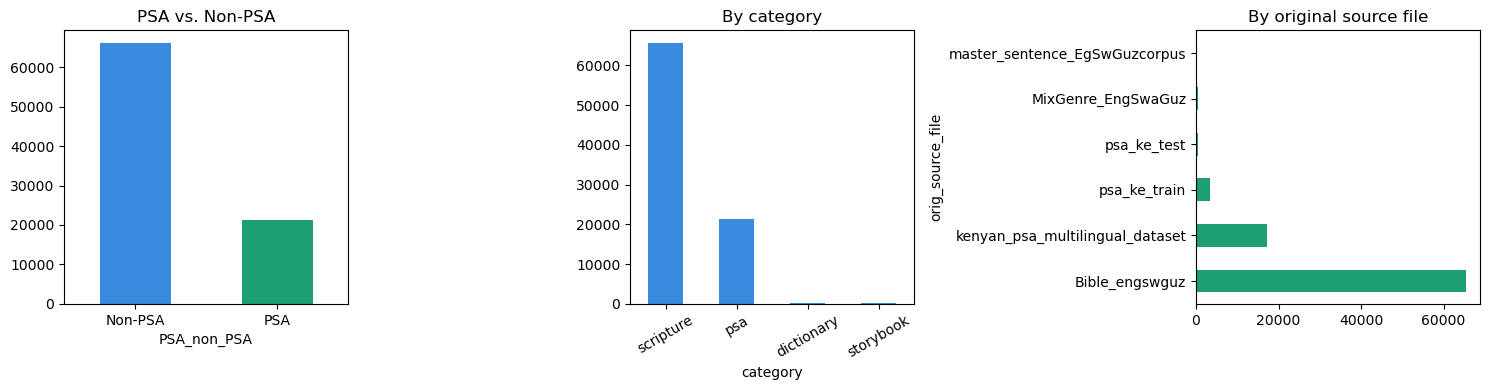

PSA_non_PSA:
PSA_non_PSA
Non-PSA    66091
PSA        21362

category:
category
scripture     65564
psa           21362
dictionary      316
storybook       211

orig_source_file:
orig_source_file
Bible_engswguz                     65528
kenyan_psa_multilingual_dataset    17197
psa_ke_train                        3509
psa_ke_test                          573
MixGenre_EngSwaGuz                   411
master_sentence_EgSwGuzcorpus        235

PSA rows by provenance (real = native-speaker-collected, synthetic = LLM-generated):
provenance
synthetic    14984
real          6365
unknown         13
-> 70% of all PSA content in the corpus is synthetic; Section 6 shows how much of that ends up in the general test set.


In [26]:
print(f"Whole deduplicated corpus: {len(whole_dataset_df):,} rows\n")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

whole_dataset_df["PSA_non_PSA"].value_counts().plot(kind="bar", ax=axes[0], color=["#378ADD", "#1D9E75"])
axes[0].set_title("PSA vs. Non-PSA")
axes[0].tick_params(axis="x", rotation=0)

whole_dataset_df["category"].value_counts().plot(kind="bar", ax=axes[1], color="#378ADD")
axes[1].set_title("By category")
axes[1].tick_params(axis="x", rotation=30)

whole_dataset_df["orig_source_file"].value_counts().plot(kind="barh", ax=axes[2], color="#1D9E75")
axes[2].set_title("By original source file")

plt.tight_layout()
plt.show()

print("PSA_non_PSA:")
print(whole_dataset_df["PSA_non_PSA"].value_counts().to_string())
print("\ncategory:")
print(whole_dataset_df["category"].value_counts().to_string())
print("\norig_source_file:")
print(whole_dataset_df["orig_source_file"].value_counts().to_string())

psa_rows = whole_dataset_df[whole_dataset_df["PSA_non_PSA"] == "PSA"]
print("\nPSA rows by provenance (real = native-speaker-collected, synthetic = LLM-generated):")
print(psa_rows["provenance"].value_counts().to_string())
print(f"-> {100 * (psa_rows['provenance'] == 'synthetic').mean():.0f}% of all PSA content in the "
      f"corpus is synthetic; Section 6 shows how much of that ends up in the general test set.")


## 4. Per-split EDA via the shared `eda.py`

### Method
`eda.eda_report()` is the same function `nllb_training.ipynb` calls on `train`/`test` - here it
runs across every flat split this notebook has (`train`, `validation_general`, `validation_psa`,
and the three test sets individually), so the training notebook's own EDA section is redundant
with, not a first look at, this data.

### Rationale
Running the identical function across every split (not just train/test) surfaces things a
two-split comparison would miss - e.g. whether `validation_general`'s length distribution actually
resembles train's (it's supposed to, being a stratified sample of the same pool) or whether one of
the three test sets has a notably different vocabulary size per row than the others (expected,
since Bible sentences run longer than PSA announcements or dictionary phrases).

=== EDA: train ===
rows: 70,480

PSA / Non-PSA composition:
PSA_non_PSA
Non-PSA    54725
PSA        15755

distinct source files (dataset_origin): 10

English length  - mean 22.9, median 21, max 688
Ekegusii length - mean 20.0, median 19, max 145


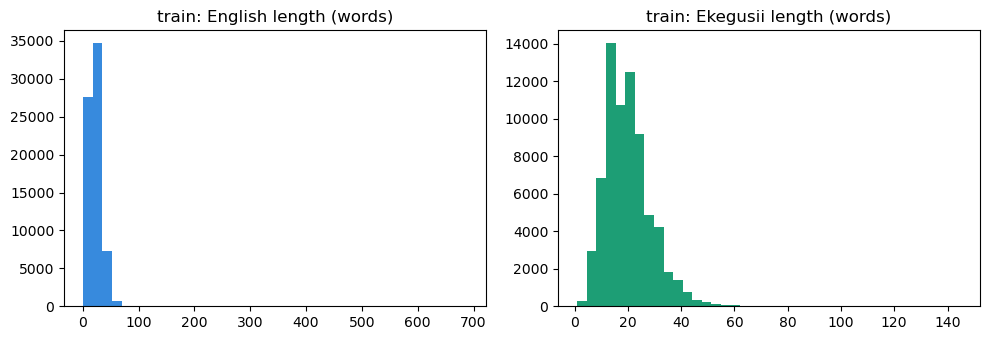


Ekegusii vocabulary size (whitespace tokens): 120,916

=== EDA: validation_general ===
rows: 6,080

PSA / Non-PSA composition:
PSA_non_PSA
Non-PSA    6080

distinct source files (dataset_origin): 6

English length  - mean 24.0, median 22, max 143
Ekegusii length - mean 19.5, median 18, max 113


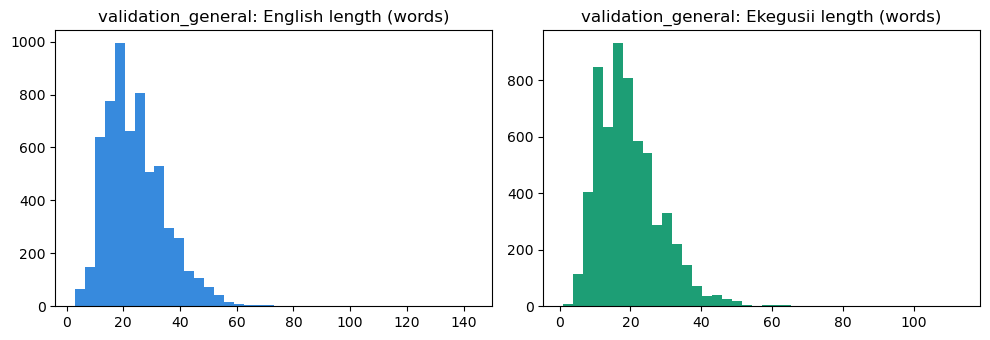


Ekegusii vocabulary size (whitespace tokens): 25,909

=== EDA: validation_psa ===
rows: 1,751

PSA / Non-PSA composition:
PSA_non_PSA
PSA    1751

distinct source files (dataset_origin): 4

English length  - mean 18.7, median 18, max 89
Ekegusii length - mean 20.9, median 20, max 81


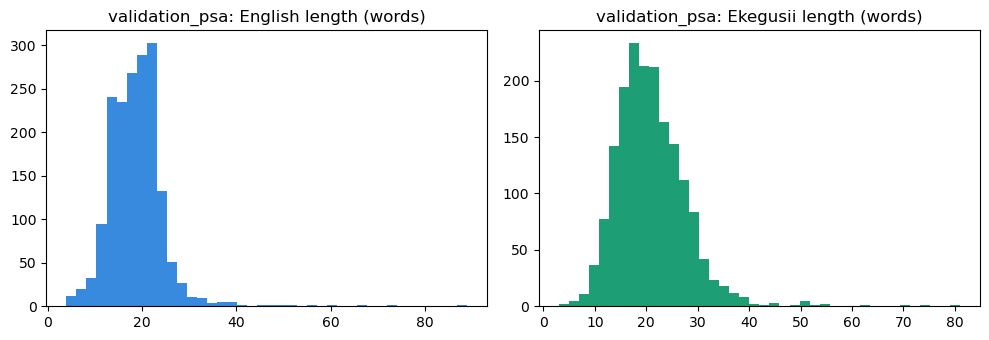


Ekegusii vocabulary size (whitespace tokens): 9,078

=== EDA: test_psa ===
rows: 1,948

PSA / Non-PSA composition:
PSA_non_PSA
PSA    1948

distinct source files (dataset_origin): 2

English length  - mean 17.8, median 16, max 55
Ekegusii length - mean 19.7, median 18, max 57


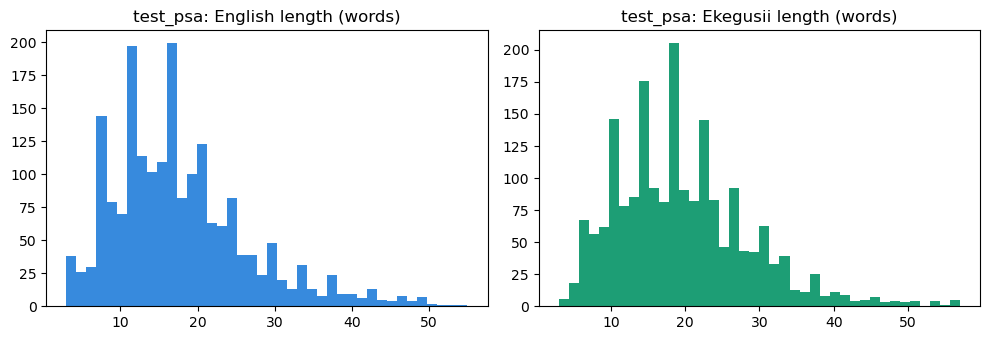


Ekegusii vocabulary size (whitespace tokens): 11,077

=== EDA: test_bible ===
rows: 2,000

PSA / Non-PSA composition:
PSA_non_PSA
Non-PSA    2000

distinct source files (dataset_origin): 3

English length  - mean 23.5, median 22, max 60
Ekegusii length - mean 19.2, median 18, max 53


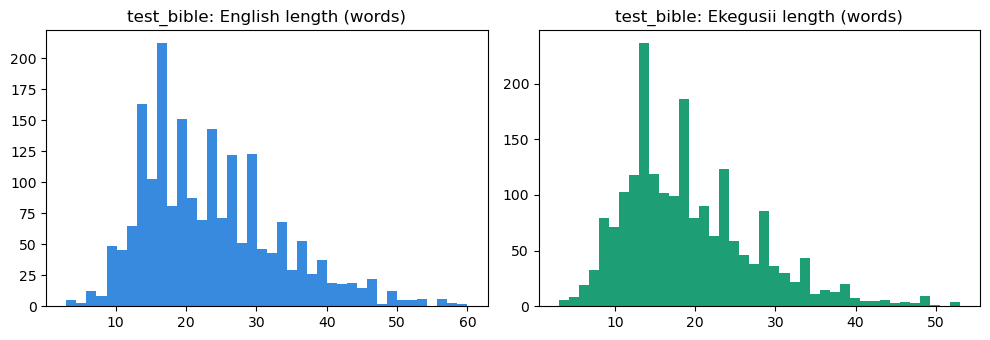


Ekegusii vocabulary size (whitespace tokens): 11,842

=== EDA: test_general ===
rows: 5,194

PSA / Non-PSA composition:
PSA_non_PSA
Non-PSA    3286
PSA        1908

distinct source files (dataset_origin): 10

English length  - mean 21.8, median 20, max 59
Ekegusii length - mean 19.8, median 19, max 59


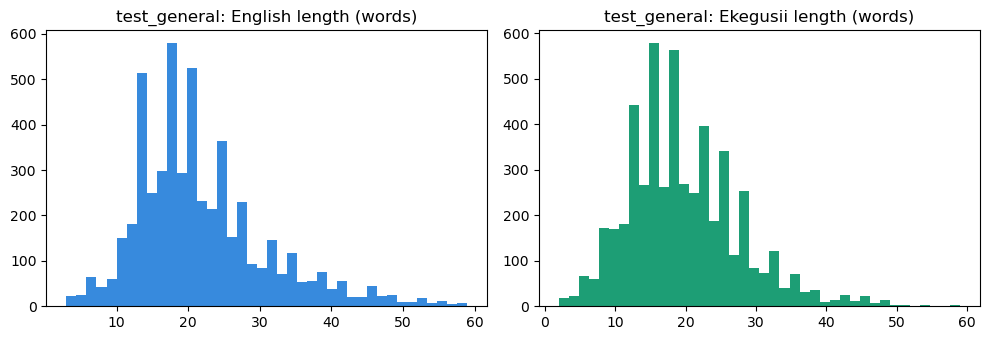


Ekegusii vocabulary size (whitespace tokens): 25,354



In [27]:
splits_to_report = [
    (flat["train"], "train"),
    (flat["validation_general"], "validation_general"),
    (flat["validation_psa"], "validation_psa"),
    (test_psa_df, "test_psa"),
    (test_bible_df, "test_bible"),
    (test_general_df, "test_general"),
]

eda_summaries = {}
for d, name in splits_to_report:
    eda_summaries[name] = eda.eda_report(d, name=name)
    print()


## 5. PSA test: domain stratification

### Method
`00_data_prep.ipynb` targeted 400 rows per domain (Agriculture/Education/Governance/Health/
Security). Confirm the actual per-domain counts, and show why Agriculture specifically falls
short.

### Rationale
This is the one place the prep notebook's target (2,000 = 400x5) wasn't fully met, and the reason
is a property of the source data worth seeing directly rather than taking on faith: Agriculture's
native-speaker PSA rows are flagged `document_extract` (pulled from a longer report, not authored
as a PSA) far more often than the other four domains, so fewer of them pass the "clean test data"
bar.

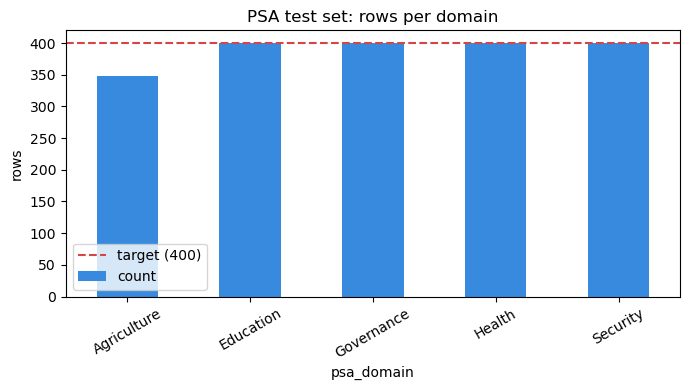

psa_domain
Agriculture    348
Education      400
Governance     400
Health         400
Security       400

Short of target: {'Agriculture': 52}


In [28]:
domain_counts = test_psa_df["psa_domain"].value_counts().reindex(
    ["Agriculture", "Education", "Governance", "Health", "Security"])

fig, ax = plt.subplots(figsize=(7, 4))
domain_counts.plot(kind="bar", ax=ax, color="#378ADD")
ax.axhline(400, color="#D64545", linestyle="--", label="target (400)")
ax.set_title("PSA test set: rows per domain")
ax.set_ylabel("rows")
ax.tick_params(axis="x", rotation=30)
ax.legend()
plt.tight_layout()
plt.show()

print(domain_counts.to_string())
shortfall = 400 - domain_counts
if (shortfall > 0).any():
    print(f"\nShort of target: {shortfall[shortfall > 0].to_dict()}")


## 6. Bible test and general test: composition breakdown

### Method
The Bible test is scripture-only by construction - break it down by which of the three
non-overlapping scripture sub-sources (`Trilingual-Bible`, `bible_ebible`, `ENG-EKE`) each row
came from, confirming none of the 135 folktale rows slipped in. The general test set is four
independent slices (bible/storybook/psa/dictionary, sized as a percentage of each source's own
remaining pool) - break it down by `category`, then look specifically at its PSA slice's
real-vs-synthetic provenance, since that's the one part of any test set here that includes
LLM-generated content by explicit choice.

### Rationale
These two sets were built from different rules than the PSA test (no domain target, no fixed
total), so "did it come out the way Section 5 of the prep notebook intended" is worth checking
directly rather than assuming the code did what the markdown said.

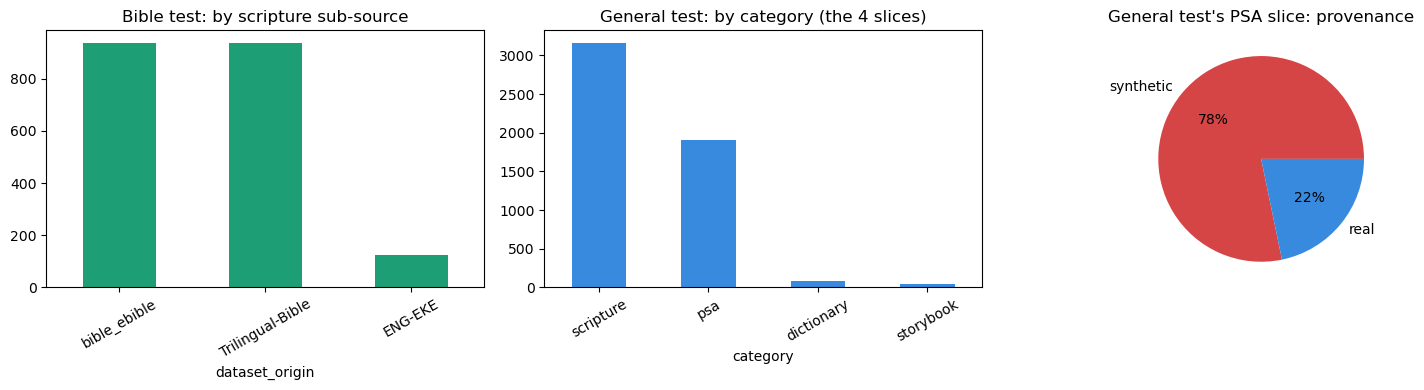

Bible test by scripture sub-source:
dataset_origin
bible_ebible        938
Trilingual-Bible    936
ENG-EKE             126

confirmed: every Bible test row has category == 'scripture' (no folktale rows present)

General test by category:
category
scripture     3166
psa           1908
dictionary      78
storybook       42

General test's PSA slice: 1,908 rows, 78% synthetic (filterable later via the 'provenance' column if a real-only cut is needed)


In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

test_bible_df["dataset_origin"].value_counts().plot(kind="bar", ax=axes[0], color="#1D9E75")
axes[0].set_title("Bible test: by scripture sub-source")
axes[0].tick_params(axis="x", rotation=30)

test_general_df["category"].value_counts().plot(kind="bar", ax=axes[1], color="#378ADD")
axes[1].set_title("General test: by category (the 4 slices)")
axes[1].tick_params(axis="x", rotation=30)

general_psa_slice = test_general_df[test_general_df["category"] == "psa"]
general_psa_slice["provenance"].value_counts().plot(
    kind="pie", ax=axes[2], autopct="%1.0f%%", colors=["#D64545", "#378ADD"], ylabel="")
axes[2].set_title("General test's PSA slice: provenance")

plt.tight_layout()
plt.show()

print("Bible test by scripture sub-source:")
print(test_bible_df["dataset_origin"].value_counts().to_string())
assert (test_bible_df["category"] == "scripture").all(), "a non-scripture row leaked into the Bible test set"
print("\nconfirmed: every Bible test row has category == 'scripture' (no folktale rows present)")

print("\nGeneral test by category:")
print(test_general_df["category"].value_counts().to_string())
print(f"\nGeneral test's PSA slice: {len(general_psa_slice):,} rows, "
      f"{100*(general_psa_slice['provenance']=='synthetic').mean():.0f}% synthetic "
      f"(filterable later via the 'provenance' column if a real-only cut is needed)")


## 7. Vocabulary and out-of-vocabulary analysis

### Method
For each test set, compute the set of distinct whitespace-tokenized Ekegusii word types, and
compare it against the same set computed from `train`. The fraction of a test set's vocabulary
that never appears in train is that test set's out-of-vocabulary (OOV) rate.

### Rationale
Ekegusii is not one of NLLB-200's original 200 languages - every Ekegusii word the model can
produce well has to come from this finetuning data specifically (Section 10 of
`00_data_prep.ipynb` notes the new `guz_Latn` token gets its embedding initialized from Kikuyu,
the closest related language NLLB already knows, precisely because there's no pretrained Ekegusii
signal to fall back on). A test set with a high OOV rate against train is, by construction, asking
the model to produce words it had comparatively little or no direct training signal for - a
useful, cheap-to-compute expectation-setter for chrF/BLEU before spending compute on the actual
experiments, and a partial explanation if e.g. the Bible test scores lower than the PSA test (or
vice versa) later on.

train Ekegusii vocabulary: 120,916 distinct word types (from 70,480 rows)

                    vocab_size  oov_types  oov_rate_pct
split                                                  
validation_general       25909       3131          12.1
validation_psa            9078       1976          21.8
test_psa                 11077       3226          29.1
test_bible               11842       1084           9.2
test_general             25354       3935          15.5


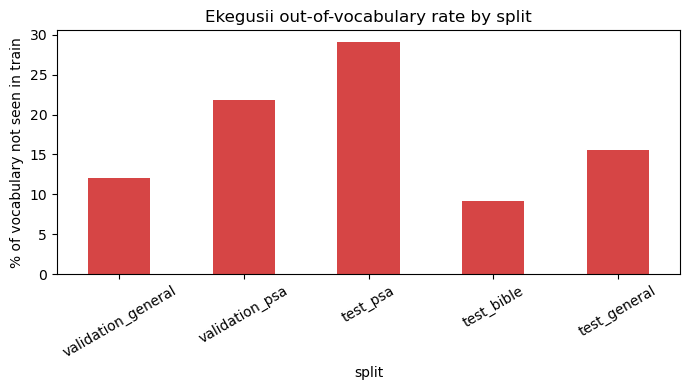

In [30]:
def vocab(df, col="Ekegusii"):
    v = set()
    for s in df[col].dropna().astype(str):
        v.update(s.lower().split())
    return v


train_vocab = vocab(flat["train"])
print(f"train Ekegusii vocabulary: {len(train_vocab):,} distinct word types "
      f"(from {len(flat['train']):,} rows)\n")

oov_rows = []
for name, d in [("validation_general", flat["validation_general"]),
                ("validation_psa", flat["validation_psa"]),
                ("test_psa", test_psa_df), ("test_bible", test_bible_df),
                ("test_general", test_general_df)]:
    v = vocab(d)
    oov = v - train_vocab
    rate = 100 * len(oov) / len(v) if v else 0.0
    oov_rows.append({"split": name, "vocab_size": len(v), "oov_types": len(oov), "oov_rate_pct": round(rate, 1)})

oov_df = pd.DataFrame(oov_rows).set_index("split")
print(oov_df.to_string())

fig, ax = plt.subplots(figsize=(7, 4))
oov_df["oov_rate_pct"].plot(kind="bar", ax=ax, color="#D64545")
ax.set_ylabel("% of vocabulary not seen in train")
ax.set_title("Ekegusii out-of-vocabulary rate by split")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


## 8. Curriculum size report + independent leakage re-verification

### Method
`eda.curriculum_size_report()` - the same call `nllb_training.ipynb` makes right after tokenizing
- prints every curriculum file's directional record count, plus the derived PSA-only count.
Then, independently of anything `00_data_prep.ipynb` already checked, rebuild the same
source-text leakage check from the public curriculum files alone (`stage1.jsonl` +
`derive_psa_only(stage2)`, which together are exactly the train-pool keys the prep notebook
itself checked against) and confirm zero of `validation_general`/`validation_psa`/`test` overlap
with train on source text.

### Rationale
This is a QA gate for *this* notebook, not a re-run of the prep notebook's internal logic - it
reads only the files `nllb_training.ipynb` will also read, so if this passes, the data as-shipped
is clean regardless of what happened inside `00_data_prep.ipynb` to produce it.

In [31]:
eda.curriculum_size_report(curriculum, psa_only_rows=psa_only_rows)

train_keys = {(r["src_lang"], r["tgt_lang"], r["src"].lower())
              for r in curriculum["stage1"] + psa_only_rows}

print("\nIndependent leakage re-check (reading only the public curriculum files):")
for name in ["validation_general", "validation_psa", "test"]:
    leaked = [r for r in curriculum[name]
              if (r["src_lang"], r["tgt_lang"], r["src"].lower()) in train_keys]
    print(f"  {name:20s} leaked against train: {len(leaked)} / {len(curriculum[name])}")


=== Curriculum sizes (direction-expanded) ===
  stage1                104,234 examples
  stage2                164,757 examples
  mixed                 227,802 examples
  validation_general      7,851 examples
  validation_psa          3,405 examples
  test                   13,629 examples
  psa_only              123,568 examples  (derived from stage2, replay rows excluded - no new file)

Independent leakage re-check (reading only the public curriculum files):
  validation_general   leaked against train: 0 / 7851
  validation_psa       leaked against train: 0 / 3405
  test                 leaked against train: 0 / 13629


## 9. Dataset datasheet summary

A single consolidated view of every number this notebook computed, in one place - meant to be
copied into a report or thesis appendix rather than re-derived from scattered cell outputs.

In [32]:
print("=" * 70)
print("DATASET DATASHEET")
print("=" * 70)
print(f"\nWhole deduplicated corpus : {len(whole_dataset_df):,} rows")
print(f"  PSA                     : {int((whole_dataset_df['PSA_non_PSA']=='PSA').sum()):,}")
print(f"  Non-PSA                 : {int((whole_dataset_df['PSA_non_PSA']=='Non-PSA').sum()):,}")

print(f"\nRow-level partition:")
for name, d in [("train", flat["train"]), ("validation_general", flat["validation_general"]),
                ("validation_psa", flat["validation_psa"]), ("test_psa", test_psa_df),
                ("test_bible", test_bible_df), ("test_general", test_general_df)]:
    print(f"  {name:20s} {len(d):>8,} rows")

print(f"\nPSA test domain counts    : {test_psa_df['psa_domain'].value_counts().to_dict()}")
print(f"General test slice sizes  : {test_general_df['category'].value_counts().to_dict()}")

print(f"\nCurriculum (directional examples):")
for name in ["stage1", "stage2", "mixed"]:
    print(f"  {name:20s} {len(curriculum[name]):>8,}")

print(f"\nEkegusii OOV rate vs. train:")
print(oov_df["oov_rate_pct"].to_string())

print(f"\nSeed: {mixture['seed']}  |  hyperparameters: {mixture['hyperparameters']}")


DATASET DATASHEET

Whole deduplicated corpus : 87,453 rows
  PSA                     : 21,362
  Non-PSA                 : 66,091

Row-level partition:
  train                  70,480 rows
  validation_general      6,080 rows
  validation_psa          1,751 rows
  test_psa                1,948 rows
  test_bible              2,000 rows
  test_general            5,194 rows

PSA test domain counts    : {'Education': 400, 'Health': 400, 'Governance': 400, 'Security': 400, 'Agriculture': 348}
General test slice sizes  : {'scripture': 3166, 'psa': 1908, 'dictionary': 78, 'storybook': 42}

Curriculum (directional examples):
  stage1                104,234
  stage2                164,757
  mixed                 227,802

Ekegusii OOV rate vs. train:
split
validation_general    12.1
validation_psa        21.8
test_psa              29.1
test_bible             9.2
test_general          15.5

Seed: 42  |  hyperparameters: {'psa_upsample': 4, 'replay_fraction': 0.25, 'min_words': 2, 'max_words': 60, 